Instalar dependencias

In [ ]:
# Transformers installation
! pip install transformers datasets evaluate accelerate
! pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# To install from source instead of the last release, comment the command above and uncomment the following one.
# ! pip install git+https://github.com/huggingface/transformers.git

Comprobar CUDA/GPU's...

In [ ]:
import os
import sys

print("ANTES CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))

# Quitar el bloqueo
os.environ.pop("CUDA_VISIBLE_DEVICES", None)

# (Opcional) fijar GPUs explícitas
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

print("DESPUÉS CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))

# IMPORTANTE: torch se importa DESPUÉS de ajustar env
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())
if torch.cuda.is_available():
    torch.cuda.init()
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))

In [ ]:
import os
import subprocess
import ctypes
import torch
from pathlib import Path

print("=== BASIC ===")
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Torch CUDA (compiled):", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())

print("\n=== ENV VARS (relevantes) ===")
for k in [
    "CUDA_VISIBLE_DEVICES",
    "NVIDIA_VISIBLE_DEVICES",
    "NVIDIA_DRIVER_CAPABILITIES",
    "LD_LIBRARY_PATH",
    "PATH",
]:
    v = os.environ.get(k, None)
    if v is None:
        print(f"{k}: <not set>")
    else:
        print(f"{k}: {v}")

print("\n=== /dev/nvidia* ===")
try:
    devs = sorted([p.as_posix() for p in Path("/dev").glob("nvidia*")])
    print("Found:", devs if devs else "<none>")
except Exception as e:
    print("Error listing /dev:", repr(e))

print("\n=== nvidia-smi ===")
try:
    out = subprocess.check_output(["nvidia-smi"], stderr=subprocess.STDOUT).decode("utf-8")
    print(out)
except Exception as e:
    print("nvidia-smi failed:", repr(e))

print("\n=== Can we load libcuda.so.1? ===")
try:
    ctypes.CDLL("libcuda.so.1")
    print("✅ libcuda.so.1 loaded OK")
except Exception as e:
    print("❌ Failed to load libcuda.so.1:", repr(e))

print("\n=== Try CUDA init to get the real error ===")
try:
    torch.cuda.init()
    print("✅ torch.cuda.init() OK")
    print("device_count after init:", torch.cuda.device_count())
    if torch.cuda.device_count() > 0:
        for i in range(torch.cuda.device_count()):
            print(f"GPU {i}:", torch.cuda.get_device_name(i))
except Exception as e:
    print("❌ torch.cuda.init() failed:", repr(e))

print("\n=== Torch config (resumen) ===")
try:
    torch.__config__.show()
except Exception as e:
    print("Could not show torch config:", repr(e))

# Task c

evaluation: Qualitative

In [ ]:
import random
from pathlib import Path
from typing import Dict, List

import torch
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from IPython.display import display

# =========================
# Helpers
# =========================
def load_font(size: int = 14) -> ImageFont.ImageFont:
    for fp in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
    ]:
        try:
            if Path(fp).exists():
                return ImageFont.truetype(fp, size=size)
        except Exception:
            pass
    return ImageFont.load_default()

def draw_detections(
    image: Image.Image,
    detections: Dict[str, torch.Tensor],
    id2label: Dict[int, str],
    keep_labels: set,
) -> Image.Image:
    img = image.copy()
    draw = ImageDraw.Draw(img)
    font = load_font(14)

    boxes = detections["boxes"].tolist()
    scores = detections["scores"].tolist()
    labels = detections["labels"].tolist()

    for (x1, y1, x2, y2), s, lab in zip(boxes, scores, labels):
        name = id2label.get(int(lab), str(lab))
        if keep_labels and name not in keep_labels:
            continue

        draw.rectangle([x1, y1, x2, y2], width=3)

        txt = f"{name} {s:.2f}"
        # textsize compat
        try:
            tw, th = draw.textsize(txt, font=font)
        except Exception:
            bbox = draw.textbbox((0, 0), txt, font=font)
            tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]

        ty1 = max(0, y1 - th - 4)
        draw.rectangle([x1, ty1, x1 + tw + 6, ty1 + th + 4], fill="black")
        draw.text((x1 + 3, ty1 + 2), txt, fill="white", font=font)

    return img

def list_kitti_rgb_images(kitti_root: Path, split: str, seqs=None) -> List[Path]:
    """
    Returns list of RGB image paths under:
      - training: KITTI_ROOT/training/image_02/<seq>/*.png
      - testing:  KITTI_ROOT/testing/image_02/<seq>/*.png
    """
    img_root = kitti_root / split / "image_02"
    if not img_root.exists():
        raise FileNotFoundError(f"Missing: {img_root}")

    seq_dirs = sorted([p for p in img_root.iterdir() if p.is_dir()])
    if seqs is not None:
        seqs_set = set(seqs)
        seq_dirs = [p for p in seq_dirs if p.name in seqs_set]

    paths: List[Path] = []
    for sd in seq_dirs:
        paths.extend(sorted(sd.glob("*.png")))
    return paths

def rel_from_split(p: Path, kitti_root: Path, split: str) -> Path:
    base = kitti_root / split
    try:
        return p.relative_to(base)
    except Exception:
        return Path(p.name)


In [ ]:


# =========================
# CONFIG (edita aquí)
# =========================
KITTI_ROOT = Path("/ghome/group03/mcv/datasets/C5/KITTI-MOTS")   # raíz que enseñaste: instances, instances_txt, training, testing
SPLIT = "testing"  # "training" | "testing"
CHECKPOINT = "facebook/detr-resnet-50"  # o "microsoft/conditional-detr-resnet-50"
THRESHOLD = 0.5
KEEP_CLASSES = {"car", "person"}  # en COCO: pedestrian ~ "person"
OUTPUT_DIR = Path("./out_detr_kitti_mots_task_c")
MAX_IMAGES = 200      # 0 = todas
SHOW_N = 8            # cuántas imágenes mostrar en el notebook (además de guardar)

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Load model
# =========================
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Loading:", CHECKPOINT)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(device)
model.eval()

id2label: Dict[int, str] = dict(model.config.id2label)

# =========================
# Collect images
# =========================
img_paths = list_kitti_rgb_images(KITTI_ROOT, SPLIT)
print(f"Found {len(img_paths)} RGB images in {SPLIT}/image_02")

if MAX_IMAGES and MAX_IMAGES > 0:
    img_paths = img_paths[:MAX_IMAGES]
    print(f"Using first {len(img_paths)} images (MAX_IMAGES={MAX_IMAGES})")

# selecciona cuáles mostrar (aleatorio para que no sean siempre las primeras)
show_set = set(random.sample(img_paths, k=min(SHOW_N, len(img_paths)))) if SHOW_N > 0 else set()

# =========================
# Inference
# =========================
shown = 0
with torch.no_grad():
    for p in tqdm(img_paths, desc="DeTR inference"):
        img = Image.open(p).convert("RGB")

        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)

        target_sizes = torch.tensor([img.size[::-1]], device=device)  # (H, W)
        results = processor.post_process_object_detection(
            outputs, threshold=THRESHOLD, target_sizes=target_sizes
        )[0]

        vis = draw_detections(img, results, id2label=id2label, keep_labels=KEEP_CLASSES)

        # guarda manteniendo subcarpetas (image_02/0000/000123.png)
        rel = rel_from_split(p, KITTI_ROOT, SPLIT)
        save_path = OUTPUT_DIR / SPLIT / rel
        save_path.parent.mkdir(parents=True, exist_ok=True)
        vis.save(save_path.with_suffix(".png"))

        # muestra algunas en el notebook
        if p in show_set and shown < SHOW_N:
            print("Showing:", str(rel))
            display(vis)
            shown += 1

print("Done. Saved to:", OUTPUT_DIR.resolve())

# Task d

In [ ]:
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from transformers import AutoImageProcessor, AutoModelForObjectDetection


# =========================
# Helper: list frames with GT + RGB
# =========================
def list_training_pairs(kitti_root: Path, seqs=None) -> List[Tuple[str, Path, Path]]:
    inst_root = kitti_root / "instances"
    rgb_root = kitti_root / "training" / "image_02"

    if not inst_root.exists():
        raise FileNotFoundError(f"Missing instances folder: {inst_root}")
    if not rgb_root.exists():
        raise FileNotFoundError(f"Missing training RGB folder: {rgb_root}")

    seq_dirs = sorted([p for p in inst_root.iterdir() if p.is_dir()])
    if seqs is not None:
        seqs_set = set(seqs)
        seq_dirs = [p for p in seq_dirs if p.name in seqs_set]

    pairs = []
    for seq_dir in seq_dirs:
        seq = seq_dir.name
        rgb_seq = rgb_root / seq
        if not rgb_seq.exists():
            continue

        for mask_path in sorted(seq_dir.glob("*.png")):
            rgb_path = rgb_seq / mask_path.name
            if rgb_path.exists():
                pairs.append((seq, rgb_path, mask_path))

    return pairs

# =========================
# Helper: GT from instance PNG -> COCO bboxes
# =========================
def extract_gt_from_instance_png(mask_path: Path) -> List[Tuple[int, List[float]]]:
    mask = np.array(Image.open(mask_path), dtype=np.int32)
    ids = np.unique(mask)
    ids = ids[ids != 0]

    gt = []
    for inst_id in ids:
        class_id = int(inst_id // 1000)
        if class_id not in KITTI_TO_COCO:
            continue

        coco_cat = KITTI_TO_COCO[class_id]
        ys, xs = np.where(mask == inst_id)
        if len(xs) == 0:
            continue

        x1 = float(xs.min())
        y1 = float(ys.min())
        x2 = float(xs.max()) + 1.0
        y2 = float(ys.max()) + 1.0
        w = x2 - x1
        h = y2 - y1
        if w <= 1.0 or h <= 1.0:
            continue

        gt.append((coco_cat, [x1, y1, w, h]))
    return gt



# =========================
# COCOeval helper
# =========================
def coco_eval_bbox(coco_gt: COCO, preds: List[Dict], img_ids: List[int], cat_ids: List[int], title: str):
    if len(preds) == 0:
        print(f"\n[{title}] No predictions -> cannot evaluate.")
        return None

    coco_dt = coco_gt.loadRes(preds)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.imgIds = img_ids
    coco_eval.params.catIds = cat_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    print(f"\n===== {title} (COCOeval bbox) =====")
    coco_eval.summarize()
    return coco_eval.stats


In [ ]:
# =========================
# Task (d): COCO evaluation on KITTI-MOTS for:
# - DeTR (COCO pretrained)
# Only sequences 0016..0020
# =========================


# =========================
# CONFIG
# =========================
KITTI_ROOT = Path("/home/mcv/datasets/C5/KITTI-MOTS")

# SECUENCIAS 16-20 (carpetas 0016..0020)
SEQS = [f"{i:04d}" for i in range(16, 21)]  # ['0016','0017','0018','0019','0020']
print("Using sequences:", SEQS)

THRESH_DETR = 0.5
DETR_CKPT = "facebook/detr-resnet-50"

# KITTI-MOTS class_id (en mask): 1=car, 2=pedestrian, 10=ignore
# COCO category_id: person=1, car=3
KITTI_TO_COCO = {1: 3, 2: 1}
EVAL_CAT_IDS = sorted(set(KITTI_TO_COCO.values()))  # [1,3]
KEEP_COCO_IDS = set(EVAL_CAT_IDS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Build COCO GT in-memory (solo SEQS)
# =========================
pairs = list_training_pairs(KITTI_ROOT, seqs=SEQS)
if not pairs:
    raise RuntimeError("No (RGB, GT mask) pairs found for the selected sequences.")

print(f"Evaluating on {len(pairs)} frames from sequences {SEQS}")

gt_images = []
gt_annotations = []
ann_id = 1

for img_id, (seq, rgb_path, mask_path) in enumerate(pairs, start=1):
    with Image.open(rgb_path) as im:
        w, h = im.size

    gt_images.append({"id": img_id, "file_name": str(rgb_path), "width": w, "height": h})

    gt_objs = extract_gt_from_instance_png(mask_path)
    for coco_cat, bbox_xywh in gt_objs:
        x, y, bw, bh = bbox_xywh
        gt_annotations.append(
            {
                "id": ann_id,
                "image_id": img_id,
                "category_id": int(coco_cat),
                "bbox": [float(x), float(y), float(bw), float(bh)],
                "area": float(bw * bh),
                "iscrowd": 0,
            }
        )
        ann_id += 1

gt_categories = [
    {"id": 1, "name": "person", "supercategory": "person"},
    {"id": 3, "name": "car", "supercategory": "vehicle"},
]

gt_dict = {"images": gt_images, "annotations": gt_annotations, "categories": gt_categories}

coco_gt = COCO()
coco_gt.dataset = gt_dict
coco_gt.createIndex()

img_ids = [img["id"] for img in gt_images]
print("GT annotations:", len(gt_annotations))
print("COCO eval catIds:", EVAL_CAT_IDS)

# =========================
# DeTR predictions
# =========================
print("\n[DeTR] Loading:", DETR_CKPT)
detr_processor = AutoImageProcessor.from_pretrained(DETR_CKPT)
detr_model = AutoModelForObjectDetection.from_pretrained(DETR_CKPT).to(device)
detr_model.eval()

detr_preds = []
with torch.no_grad():
    for img_id, (seq, rgb_path, mask_path) in tqdm(list(zip(img_ids, pairs)), desc="DeTR preds", total=len(pairs)):
        img = Image.open(rgb_path).convert("RGB")

        inputs = detr_processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = detr_model(**inputs)

        target_sizes = torch.tensor([img.size[::-1]], device=device)  # (H,W)
        results = detr_processor.post_process_object_detection(
            outputs, threshold=THRESH_DETR, target_sizes=target_sizes
        )[0]

        boxes = results["boxes"].detach().cpu().numpy()   # xyxy
        scores = results["scores"].detach().cpu().numpy()
        labels = results["labels"].detach().cpu().numpy() # COCO ids

        for (x1, y1, x2, y2), s, lab in zip(boxes, scores, labels):
            lab = int(lab)
            if lab not in KEEP_COCO_IDS:
                continue
            w = float(x2 - x1)
            h = float(y2 - y1)
            if w <= 1.0 or h <= 1.0:
                continue
            detr_preds.append(
                {
                    "image_id": int(img_id),
                    "category_id": lab,
                    "bbox": [float(x1), float(y1), w, h],
                    "score": float(s),
                }
            )

detr_stats = coco_eval_bbox(coco_gt, detr_preds, img_ids, EVAL_CAT_IDS, title=f"DeTR (COCO pretrained) - SEQS {SEQS}")

In [ ]:
import matplotlib.pyplot as plt

# 1) Recuperar stats
# Si en la celda anterior guardaste: detr_stats = coco_eval_bbox(...)
# entonces usa detr_stats. Si no, intenta usar "_" (que tú asignaste).
if "detr_stats" in globals() and detr_stats is not None:
    stats = np.array(detr_stats, dtype=float)
elif "_" in globals() and _ is not None:
    stats = np.array(_, dtype=float)
else:
    raise ValueError("No encuentro las métricas. Guarda el retorno: detr_stats = coco_eval_bbox(...) y vuelve a ejecutar.")

labels = [
    "AP@[.50:.95]", "AP@0.50", "AP@0.75", "AP_small", "AP_medium", "AP_large",
    "AR@1", "AR@10", "AR@100", "AR_small", "AR_medium", "AR_large"
]

# 2) Print tipo tabla
print("COCOeval stats (0..1):")
for name, val in zip(labels, stats):
    print(f"{name:>12}: {val:.3f}")

# 3) Plot (1 figura)
x = np.arange(len(labels))

plt.figure(figsize=(12, 4))
plt.bar(x, stats)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.title("COCOeval metrics (DeTR COCO-pretrained on KITTI-MOTS)")
plt.ylabel("score (0..1)")
plt.tight_layout()
plt.show()

# task e

In [ ]:
# =========================
# Task (e) - Fine-tune DeTR (Hugging Face) on KITTI-MOTS
# Train: 0000..0015
# Val:   0016..0020 (puedes cambiarlo)
#
# FIXES:
# - Force single GPU to avoid DataParallel StopIteration
# - Force use_fast=False (avoid SizeDict.keys crash)
# - Apply processor in collate_fn (batch padding) to avoid stack-size mismatch
# =========================

# --- MUST be first (before torch import) ---
import os
import sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")  # usa solo GPU 0 (evita DataParallel)

if "torch" in sys.modules:
    print("⚠️ torch ya estaba importado. Reinicia el kernel para que CUDA_VISIBLE_DEVICES tenga efecto.")

# --- imports ---
import random
import inspect
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import albumentations as A

from pycocotools.coco import COCO

from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer,
)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -------------------------
# CONFIG
# -------------------------
KITTI_ROOT = Path("/home/mcv/datasets/C5/KITTI-MOTS")

TRAIN_SEQS = [f"{i:04d}" for i in range(0, 16)]   # 0000..0015
VAL_SEQS   = [f"{i:04d}" for i in range(16, 21)]  # 0016..0020 (edita si quieres)

CHECKPOINT = "facebook/detr-resnet-50"  # o "microsoft/conditional-detr-resnet-50"
OUTPUT_DIR = "./detr_finetune_kitti_0_15_single_gpu"

NUM_EPOCHS = 5
LR = 5e-5
WEIGHT_DECAY = 1e-4
TRAIN_BS = 1          # <-- empieza en 1 (más estable); luego sube si quieres
EVAL_BS = 1
NUM_WORKERS = 2       # si da problemas, pon 0

EVAL_THRESHOLD = 0.5

IMAGE_SIZE = 480      # shortest edge
LONGEST_EDGE = 1333

# KITTI-MOTS class_id en mask: 1=car, 2=pedestrian/person
# Para entrenar DETR conviene ids contiguos 0..C-1
KITTI_CLASS_TO_TRAIN_ID = {1: 0, 2: 1}
ID2LABEL = {0: "car", 1: "person"}
LABEL2ID = {"car": 0, "person": 1}
EVAL_CAT_IDS = [0, 1]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Train seqs:", TRAIN_SEQS)
print("Val   seqs:", VAL_SEQS)

# -------------------------
# Helpers: list (rgb, mask) pairs
# -------------------------
def list_pairs(kitti_root: Path, seqs: List[str]) -> List[Tuple[str, Path, Path]]:
    inst_root = kitti_root / "instances"
    rgb_root = kitti_root / "training" / "image_02"
    pairs: List[Tuple[str, Path, Path]] = []

    for seq in seqs:
        seq_inst = inst_root / seq
        seq_rgb  = rgb_root / seq
        if not seq_inst.exists() or not seq_rgb.exists():
            print(f"[WARN] Missing seq folder (skip): {seq}")
            continue

        for mask_path in sorted(seq_inst.glob("*.png")):
            rgb_path = seq_rgb / mask_path.name
            if rgb_path.exists():
                pairs.append((seq, rgb_path, mask_path))

    return pairs

# -------------------------
# Helpers: extract GT bboxes from instance mask PNG
# -------------------------
def extract_bboxes_from_instance_png(mask_path: Path) -> Tuple[List[int], List[List[float]]]:
    """
    Returns (train_class_ids, bboxes_xywh):
      - train_class_ids are 0..1 for training
      - bboxes are COCO format [x,y,w,h] in pixels
    """
    mask = np.array(Image.open(mask_path), dtype=np.int32)
    ids = np.unique(mask)
    ids = ids[ids != 0]  # background

    cats: List[int] = []
    bboxes: List[List[float]] = []

    for inst_id in ids:
        class_id = int(inst_id // 1000)
        if class_id not in KITTI_CLASS_TO_TRAIN_ID:
            continue
        train_cat = KITTI_CLASS_TO_TRAIN_ID[class_id]

        ys, xs = np.where(mask == inst_id)
        if len(xs) == 0:
            continue

        x1 = float(xs.min())
        y1 = float(ys.min())
        x2 = float(xs.max()) + 1.0
        y2 = float(ys.max()) + 1.0
        w = x2 - x1
        h = y2 - y1
        if w <= 1.0 or h <= 1.0:
            continue

        cats.append(int(train_cat))
        bboxes.append([x1, y1, w, h])

    return cats, bboxes

def sanitize_coco_bboxes(bboxes: List[List[float]], cats: List[int], img_w: int, img_h: int, min_size_px: float = 2.0):
    clean_bboxes, clean_cats = [], []
    for bb, cat in zip(bboxes, cats):
        if bb is None or len(bb) != 4:
            continue
        x, y, w, h = map(float, bb)
        if w <= 0 or h <= 0:
            continue

        x1, y1 = x, y
        x2, y2 = x + w, y + h

        if x2 <= 0 or y2 <= 0 or x1 >= img_w or y1 >= img_h:
            continue

        x1 = max(0.0, min(x1, img_w - 1.0))
        y1 = max(0.0, min(y1, img_h - 1.0))
        x2 = max(0.0, min(x2, float(img_w)))
        y2 = max(0.0, min(y2, float(img_h)))

        nw, nh = x2 - x1, y2 - y1
        if nw < min_size_px or nh < min_size_px:
            continue

        clean_bboxes.append([x1, y1, nw, nh])
        clean_cats.append(int(cat))

    return clean_cats, clean_bboxes

def format_annotations_for_processor(image_id: int, cats: List[int], bboxes_xywh: List[List[float]]) -> Dict[str, Any]:
    anns = []
    for cat, bb in zip(cats, bboxes_xywh):
        x, y, w, h = map(float, bb)
        anns.append(
            {
                "image_id": int(image_id),
                "category_id": int(cat),
                "bbox": [x, y, w, h],
                "area": float(w * h),
                "iscrowd": 0,
            }
        )
    return {"image_id": int(image_id), "annotations": anns}

# -------------------------
# Albumentations transforms
# -------------------------
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.4),
        A.HueSaturationValue(p=0.2),
        A.MotionBlur(p=0.1),
        A.Perspective(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["category"],
        clip=True,
        min_area=9,
        min_visibility=0.01,
        check_each_transform=False,
    ),
)

val_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["category"],
        clip=True,
        min_area=1,
        min_visibility=0.0,
        check_each_transform=False,
    ),
)

# -------------------------
# Dataset: returns raw image + annotations (NO processor here)
# -------------------------
class KittiMotsRawDataset(torch.utils.data.Dataset):
    def __init__(self, pairs: List[Tuple[str, Path, Path]], transform, start_image_id: int = 1):
        self.pairs = pairs
        self.transform = transform
        self.image_ids = list(range(start_image_id, start_image_id + len(pairs)))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        seq, rgb_path, mask_path = self.pairs[idx]
        image_id = self.image_ids[idx]

        img = Image.open(rgb_path).convert("RGB")
        img_np = np.array(img)
        h, w = img_np.shape[:2]

        cats, bboxes = extract_bboxes_from_instance_png(mask_path)
        cats, bboxes = sanitize_coco_bboxes(bboxes, cats, img_w=w, img_h=h, min_size_px=2.0)

        out = self.transform(image=img_np, bboxes=bboxes, category=cats)
        ann = format_annotations_for_processor(image_id, out["category"], out["bboxes"])

        return {"image": out["image"], "annotations": ann}

# -------------------------
# Processor + Model
# -------------------------
processor = AutoImageProcessor.from_pretrained(CHECKPOINT, use_fast=False)
processor.do_resize = True
processor.size = {"shortest_edge": int(IMAGE_SIZE), "longest_edge": int(LONGEST_EDGE)}
processor.do_pad = True  # padding en batch

print("Processor class:", processor.__class__.__name__)
print("Processor size:", processor.size)

model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
).to(device)

# -------------------------
# Build datasets
# -------------------------
train_pairs = list_pairs(KITTI_ROOT, TRAIN_SEQS)
val_pairs   = list_pairs(KITTI_ROOT, VAL_SEQS)

if len(train_pairs) == 0:
    raise RuntimeError("No train pairs found. Check KITTI_ROOT and TRAIN_SEQS.")
if len(val_pairs) == 0:
    raise RuntimeError("No val pairs found. Check KITTI_ROOT and VAL_SEQS.")

print(f"Train frames: {len(train_pairs)}")
print(f"Val   frames: {len(val_pairs)}")

train_ds = KittiMotsRawDataset(train_pairs, transform=train_transform, start_image_id=1)
val_ds   = KittiMotsRawDataset(val_pairs,   transform=val_transform,   start_image_id=1)

# -------------------------
# collate_fn: processor on batch -> padding solved here
# -------------------------
def collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    images = [x["image"] for x in batch]
    annotations = [x["annotations"] for x in batch]
    enc = processor(images=images, annotations=annotations, return_tensors="pt")
    return enc

# -------------------------
# TrainingArguments (eval_strategy vs evaluation_strategy)
# -------------------------
ta_kwargs = dict(
    output_dir=OUTPUT_DIR,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    dataloader_num_workers=NUM_WORKERS,
    fp16=(device.type == "cuda"),
    logging_steps=50,
    save_strategy="epoch",
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to="none",
)

ta_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
if "eval_strategy" in ta_params:
    ta_kwargs["eval_strategy"] = "epoch"
else:
    ta_kwargs["evaluation_strategy"] = "epoch"

ta_kwargs = {k: v for k, v in ta_kwargs.items() if k in ta_params}
training_args = TrainingArguments(**ta_kwargs)

# -------------------------
# Trainer
# -------------------------
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    processing_class=processor,
    tokenizer=processor,
)
tr_params = set(inspect.signature(Trainer.__init__).parameters.keys())
trainer_kwargs = {k: v for k, v in trainer_kwargs.items() if k in tr_params}
trainer = Trainer(**trainer_kwargs)

# -------------------------
# Train
# -------------------------
train_out = trainer.train()
print("Training done.")

# -------------------------
# Official COCOeval on val
# -------------------------
def build_coco_gt_from_pairs(pairs: List[Tuple[str, Path, Path]]) -> Tuple[COCO, List[int]]:
    images = []
    annotations = []
    ann_id = 1

    for img_id, (seq, rgb_path, mask_path) in enumerate(pairs, start=1):
        with Image.open(rgb_path) as im:
            w, h = im.size
        images.append({"id": img_id, "file_name": str(rgb_path), "width": w, "height": h})

        cats, bboxes = extract_bboxes_from_instance_png(mask_path)
        for cat, bb in zip(cats, bboxes):
            x, y, bw, bh = map(float, bb)
            if bw <= 1.0 or bh <= 1.0:
                continue
            annotations.append(
                {
                    "id": ann_id,
                    "image_id": img_id,
                    "category_id": int(cat),
                    "bbox": [x, y, bw, bh],
                    "area": float(bw * bh),
                    "iscrowd": 0,
                }
            )
            ann_id += 1

    categories = [
        {"id": 0, "name": "car", "supercategory": "vehicle"},
        {"id": 1, "name": "person", "supercategory": "person"},
    ]

    gt_dict = {"images": images, "annotations": annotations, "categories": categories}
    coco_gt = COCO()
    coco_gt.dataset = gt_dict
    coco_gt.createIndex()
    img_ids = [img["id"] for img in images]
    return coco_gt, img_ids

@torch.no_grad()
def run_model_preds_coco(model, processor, pairs: List[Tuple[str, Path, Path]], threshold: float) -> List[Dict[str, Any]]:
    model.eval()
    preds: List[Dict[str, Any]] = []

    for img_id, (seq, rgb_path, mask_path) in tqdm(list(enumerate(pairs, start=1)), desc="Predict (val)", total=len(pairs)):
        img = Image.open(rgb_path).convert("RGB")
        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)

        target_sizes = torch.tensor([img.size[::-1]], device=device)  # (H,W)
        results = processor.post_process_object_detection(outputs, threshold=threshold, target_sizes=target_sizes)[0]

        boxes = results["boxes"].detach().cpu().numpy()
        scores = results["scores"].detach().cpu().numpy()
        labels = results["labels"].detach().cpu().numpy()

        for (x1, y1, x2, y2), s, lab in zip(boxes, scores, labels):
            lab = int(lab)
            if lab not in EVAL_CAT_IDS:
                continue
            w = float(x2 - x1)
            h = float(y2 - y1)
            if w <= 1.0 or h <= 1.0:
                continue
            preds.append(
                {
                    "image_id": int(img_id),
                    "category_id": int(lab),
                    "bbox": [float(x1), float(y1), w, h],
                    "score": float(s),
                }
            )
    return preds

def coco_eval_bbox(coco_gt: COCO, preds: List[Dict[str, Any]], img_ids: List[int], cat_ids: List[int], title: str):
    if len(preds) == 0:
        print(f"[{title}] No predictions -> cannot evaluate.")
        return None
    coco_dt = coco_gt.loadRes(preds)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.imgIds = img_ids
    coco_eval.params.catIds = cat_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    print(f"\n===== {title} (OFFICIAL COCOeval bbox) =====")
    coco_eval.summarize()
    return coco_eval.stats

print("\nBuilding COCO GT for val...")
coco_gt, val_img_ids = build_coco_gt_from_pairs(val_pairs)

print("Running predictions for official COCO eval...")
val_preds = run_model_preds_coco(model, processor, val_pairs, threshold=EVAL_THRESHOLD)

detr_ft_stats = coco_eval_bbox(
    coco_gt,
    val_preds,
    val_img_ids,
    EVAL_CAT_IDS,
    title=f"DeTR fine-tuned on {TRAIN_SEQS} (eval on {VAL_SEQS})"
)

# Guardar el modelo fine-tuned (importante)
trainer.save_model(OUTPUT_DIR)
print("Saved fine-tuned model to:", OUTPUT_DIR)


evaluation: Qualitative

In [ ]:
# =========================
# QUALITATIVE - DeTR fine-tuned on KITTI-MOTS
# - Runs inference on KITTI-MOTS split images (training or testing)
# - Saves visualizations and optionally displays a few
# =========================

# -------------------------
# CONFIG (edita aquí)
# -------------------------
KITTI_ROOT = Path("/home/mcv/datasets/C5/KITTI-MOTS")   # ajusta si hace falta
SPLIT = "testing"  # "training" | "testing"
SEQS = None        # None = todas; o lista ["0000","0001",...]
THRESHOLD = 0.5
KEEP_CLASSES = {"car", "person"}  # en COCO: pedestrian ~ "person"
OUTPUT_DIR = Path("./out_detr_kitti_mots_task_e_qual")
MAX_IMAGES = 200      # 0 = todas
SHOW_N = 8            # cuántas mostrar en el notebook

# IMPORTANT: tu modelo fine-tuned guardado
FINETUNED_DIR = Path("./detr_finetune_kitti_0_15_single_gpu")  # pon aquí tu OUTPUT_DIR real
BASE_PROCESSOR_CKPT = "facebook/detr-resnet-50"  # processor base (estable)

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Load processor + model (fine-tuned)
# -------------------------
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Loading fine-tuned model from:", FINETUNED_DIR)
processor = AutoImageProcessor.from_pretrained(BASE_PROCESSOR_CKPT, use_fast=False)
processor.do_resize = True
processor.size = {"shortest_edge": 480, "longest_edge": 1333}
processor.do_pad = True

model = AutoModelForObjectDetection.from_pretrained(FINETUNED_DIR).to(device)
model.eval()

id2label: Dict[int, str] = dict(model.config.id2label)
print("Model id2label:", id2label)

# -------------------------
# Collect images
# -------------------------
img_paths = list_kitti_rgb_images(KITTI_ROOT, SPLIT, seqs=SEQS)
print(f"Found {len(img_paths)} RGB images in {SPLIT}/image_02")

if MAX_IMAGES and MAX_IMAGES > 0:
    img_paths = img_paths[:MAX_IMAGES]
    print(f"Using first {len(img_paths)} images (MAX_IMAGES={MAX_IMAGES})")

show_set = set(random.sample(img_paths, k=min(SHOW_N, len(img_paths)))) if SHOW_N > 0 else set()

# -------------------------
# Inference + save
# -------------------------
shown = 0
with torch.no_grad():
    for p in tqdm(img_paths, desc="DeTR qualitative"):
        img = Image.open(p).convert("RGB")

        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)

        target_sizes = torch.tensor([img.size[::-1]], device=device)  # (H, W)
        results = processor.post_process_object_detection(
            outputs, threshold=THRESHOLD, target_sizes=target_sizes
        )[0]

        vis = draw_detections(img, results, id2label=id2label, keep_labels=KEEP_CLASSES)

        rel = rel_from_split(p, KITTI_ROOT, SPLIT)
        save_path = OUTPUT_DIR / SPLIT / rel
        save_path.parent.mkdir(parents=True, exist_ok=True)
        vis.save(save_path.with_suffix(".png"))

        if p in show_set and shown < SHOW_N:
            print("Showing:", str(rel))
            display(vis)
            shown += 1

print("Done. Saved to:", OUTPUT_DIR.resolve())

evaluation: Quantitative

In [ ]:
# =========================
# QUANTITATIVE - Official COCO metrics (COCOeval) for fine-tuned DeTR
# Eval split must be training sequences (because only training has GT masks).
# Example: eval on sequences 0016..0020
# =========================

from pathlib import Path
from typing import Dict, List, Tuple, Any
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
from pycocotools.coco import COCO
from transformers import AutoImageProcessor, AutoModelForObjectDetection

# -------------------------
# CONFIG
# -------------------------
KITTI_ROOT = Path("/home/mcv/datasets/C5/KITTI-MOTS")
VAL_SEQS = [f"{i:04d}" for i in range(16, 21)]  # 0016..0020
THRESH = 0.5

# Fine-tuned model dir
FINETUNED_DIR = Path("./detr_finetune_kitti_0_15_single_gpu")  # tu OUTPUT_DIR real
BASE_PROCESSOR_CKPT = "facebook/detr-resnet-50"

# KITTI class_id -> train ids used in fine-tuning (0..1)
KITTI_CLASS_TO_TRAIN_ID = {1: 0, 2: 1}
EVAL_CAT_IDS = [0, 1]

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# Helpers
# -------------------------
def list_training_pairs(kitti_root: Path, seqs=None) -> List[Tuple[str, Path, Path]]:
    inst_root = kitti_root / "instances"
    rgb_root = kitti_root / "training" / "image_02"

    seq_dirs = sorted([p for p in inst_root.iterdir() if p.is_dir()])
    if seqs is not None:
        seqs_set = set(seqs)
        seq_dirs = [p for p in seq_dirs if p.name in seqs_set]

    pairs = []
    for seq_dir in seq_dirs:
        seq = seq_dir.name
        rgb_seq = rgb_root / seq
        if not rgb_seq.exists():
            continue
        for mask_path in sorted(seq_dir.glob("*.png")):
            rgb_path = rgb_seq / mask_path.name
            if rgb_path.exists():
                pairs.append((seq, rgb_path, mask_path))
    return pairs

def extract_gt_from_instance_png(mask_path: Path) -> List[Tuple[int, List[float]]]:
    """
    GT bboxes from KITTI-MOTS instance mask.
    Returns list of (train_category_id 0/1, bbox_xywh).
    """
    mask = np.array(Image.open(mask_path), dtype=np.int32)
    ids = np.unique(mask)
    ids = ids[ids != 0]

    gt = []
    for inst_id in ids:
        class_id = int(inst_id // 1000)
        if class_id not in KITTI_CLASS_TO_TRAIN_ID:
            continue
        cat = KITTI_CLASS_TO_TRAIN_ID[class_id]

        ys, xs = np.where(mask == inst_id)
        if len(xs) == 0:
            continue

        x1 = float(xs.min())
        y1 = float(ys.min())
        x2 = float(xs.max()) + 1.0
        y2 = float(ys.max()) + 1.0
        w = x2 - x1
        h = y2 - y1
        if w <= 1.0 or h <= 1.0:
            continue

        gt.append((int(cat), [x1, y1, w, h]))
    return gt

def coco_eval_bbox(coco_gt: COCO, preds: List[Dict[str, Any]], img_ids: List[int], cat_ids: List[int], title: str):
    if len(preds) == 0:
        print(f"\n[{title}] No predictions -> cannot evaluate.")
        return None
    coco_dt = coco_gt.loadRes(preds)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.imgIds = img_ids
    coco_eval.params.catIds = cat_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    print(f"\n===== {title} (COCOeval bbox) =====")
    coco_eval.summarize()
    return coco_eval.stats

# -------------------------
# Build GT (COCO format in-memory)
# -------------------------
pairs = list_training_pairs(KITTI_ROOT, seqs=VAL_SEQS)
if not pairs:
    raise RuntimeError("No pairs found for the selected VAL_SEQS. Check paths.")

print(f"Evaluating on {len(pairs)} frames from sequences {VAL_SEQS}")

gt_images = []
gt_annotations = []
ann_id = 1

for img_id, (seq, rgb_path, mask_path) in enumerate(pairs, start=1):
    with Image.open(rgb_path) as im:
        w, h = im.size
    gt_images.append({"id": img_id, "file_name": str(rgb_path), "width": w, "height": h})

    gt_objs = extract_gt_from_instance_png(mask_path)
    for cat, bbox_xywh in gt_objs:
        x, y, bw, bh = bbox_xywh
        gt_annotations.append(
            {
                "id": ann_id,
                "image_id": img_id,
                "category_id": int(cat),
                "bbox": [float(x), float(y), float(bw), float(bh)],
                "area": float(bw * bh),
                "iscrowd": 0,
            }
        )
        ann_id += 1

gt_categories = [
    {"id": 0, "name": "car", "supercategory": "vehicle"},
    {"id": 1, "name": "person", "supercategory": "person"},
]

gt_dict = {"images": gt_images, "annotations": gt_annotations, "categories": gt_categories}

coco_gt = COCO()
coco_gt.dataset = gt_dict
coco_gt.createIndex()

img_ids = [img["id"] for img in gt_images]
print("GT annotations:", len(gt_annotations))

# -------------------------
# Load fine-tuned model
# -------------------------
processor = AutoImageProcessor.from_pretrained(BASE_PROCESSOR_CKPT, use_fast=False)
processor.do_resize = True
processor.size = {"shortest_edge": 480, "longest_edge": 1333}
processor.do_pad = True

model = AutoModelForObjectDetection.from_pretrained(FINETUNED_DIR).to(device)
model.eval()

print("Model id2label:", dict(model.config.id2label))

# -------------------------
# Predictions -> COCO detections
# -------------------------
preds = []
with torch.no_grad():
    for img_id, (seq, rgb_path, mask_path) in tqdm(list(zip(img_ids, pairs)), desc="Predict", total=len(pairs)):
        img = Image.open(rgb_path).convert("RGB")

        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)

        target_sizes = torch.tensor([img.size[::-1]], device=device)
        res = processor.post_process_object_detection(outputs, threshold=THRESH, target_sizes=target_sizes)[0]

        boxes = res["boxes"].detach().cpu().numpy()   # xyxy
        scores = res["scores"].detach().cpu().numpy()
        labels = res["labels"].detach().cpu().numpy() # 0/1 (fine-tuned)

        for (x1, y1, x2, y2), s, lab in zip(boxes, scores, labels):
            lab = int(lab)
            if lab not in EVAL_CAT_IDS:
                continue
            w = float(x2 - x1)
            h = float(y2 - y1)
            if w <= 1.0 or h <= 1.0:
                continue
            preds.append(
                {"image_id": int(img_id), "category_id": lab, "bbox": [float(x1), float(y1), w, h], "score": float(s)}
            )

detr_ft_stats = coco_eval_bbox(
    coco_gt,
    preds,
    img_ids,
    EVAL_CAT_IDS,
    title=f"DeTR fine-tuned (eval seqs {VAL_SEQS})"
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Recuperar stats
# Si en la celda anterior guardaste: detr_stats = coco_eval_bbox(...)
# entonces usa detr_stats. Si no, intenta usar "_" (que tú asignaste).
if "detr_ft_stats" in globals() and detr_ft_stats is not None:
    stats = np.array(detr_ft_stats, dtype=float)
elif "_" in globals() and _ is not None:
    stats = np.array(_, dtype=float)
else:
    raise ValueError("No encuentro las métricas. Guarda el retorno: detr_stats = coco_eval_bbox(...) y vuelve a ejecutar.")

labels = [
    "AP@[.50:.95]", "AP@0.50", "AP@0.75", "AP_small", "AP_medium", "AP_large",
    "AR@1", "AR@10", "AR@100", "AR_small", "AR_medium", "AR_large"
]

# 2) Print tipo tabla
print("COCOeval stats (0..1):")
for name, val in zip(labels, stats):
    print(f"{name:>12}: {val:.3f}")

# 3) Plot (1 figura)
x = np.arange(len(labels))

plt.figure(figsize=(12, 4))
plt.bar(x, stats)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.title("COCOeval metrics (DeTR COCO-pretrained on KITTI-MOTS)")
plt.ylabel("score (0..1)")
plt.tight_layout()
plt.show()

# task f

In [1]:
# ============================================================
# Task (f) - Fine-tune DeTR on DEArt (biglam/european_art)
# FIX:
# - Handle row-relative category IDs dynamically
# - Filter annotations against CLASS_MAPPING
# - Map all valid classes to label 1 
# - fp16 OFF (avoid NaNs in predicted boxes during Hungarian/GIoU)
# - bbox sanitize/clip after Albumentations
# ============================================================

!pip install timm

import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import json
import random
import inspect
from typing import Any, Dict, List, Tuple

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

import albumentations as A
from datasets import load_dataset, get_dataset_config_names

from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer,
)

# -----------------------
# CONFIG
# -----------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

CHECKPOINT = "facebook/detr-resnet-50"

DATASET_NAME = "biglam/european_art"
PREFERRED_CONFIG = "coco"   # if available, use it; else fallback to "default"

VAL_RATIO = 0.2

# debug rápido (0 = todo)
MAX_TRAIN_SAMPLES = 0
MAX_VAL_SAMPLES = 0

OUTPUT_DIR = "./out_task_f_detr_deart_single_gpu_fp32"
LR = 5e-5
WEIGHT_DECAY = 1e-4
EPOCHS = 3
TRAIN_BS = 2
EVAL_BS = 2
NUM_WORKERS = 4

USE_FP16 = False

# -----------------------
# DEVICE
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# -----------------------
# Load dataset
# -----------------------
configs = get_dataset_config_names(DATASET_NAME)
CONFIG = PREFERRED_CONFIG if PREFERRED_CONFIG in configs else configs[0]
print("Using config:", CONFIG)

ds = load_dataset(DATASET_NAME, CONFIG)
base = ds["train"]

split = base.train_test_split(test_size=VAL_RATIO, seed=SEED)
train_hf = split["train"]
val_hf = split["test"]

if MAX_TRAIN_SAMPLES and MAX_TRAIN_SAMPLES > 0:
    train_hf = train_hf.select(range(min(MAX_TRAIN_SAMPLES, len(train_hf))))
if MAX_VAL_SAMPLES and MAX_VAL_SAMPLES > 0:
    val_hf = val_hf.select(range(min(MAX_VAL_SAMPLES, len(val_hf))))

print("Train size:", len(train_hf), "| Val size:", len(val_hf))

# -----------------------
# Class Mapping Rules
# -----------------------
CLASS_MAPPING = {
    "person": 1,
    "nude": 1,
    "angel": 1,
    "knight": 1,
    "monk": 1,
    "crucifixion": 1,
    "god the father": 1,
    "shepherd": 1,
    "saturno": 1,
    "judith": 1
}

# We hardcode the labels because we map all valid items to 1.
# 0 acts as a background or unused class to ensure ID 1 is valid in the model architecture.
num_labels = 2
id2label = {0: "unlabeled", 1: "target_class"}
label2id = {v: k for k, v in id2label.items()}

# Global fallback mapping for native HF Lists (Case A)
global_hf_cat_map = {}
if "annotations" in train_hf.features:
    ann_feat = train_hf.features["annotations"]
    if hasattr(ann_feat, "feature") and "category_id" in ann_feat.feature:
        names = ann_feat.feature["category_id"].names
        global_hf_cat_map = {i: name.lower() for i, name in enumerate(names)}

# -----------------------
# Helpers to normalize example
# -----------------------
def safe_int(x, fallback: int) -> int:
    try:
        return int(x)
    except Exception:
        return int(fallback)

def normalize_example(ex: Dict[str, Any], idx: int) -> Tuple[Image.Image, int, List[Dict[str, Any]]]:
    img: Image.Image = ex["image"].convert("RGB")

    # Case A: already list (Native HF Config)
    if isinstance(ex.get("annotations", None), list):
        image_id = safe_int(ex.get("image_id", idx), idx)
        anns_out = []
        for a in ex["annotations"]:
            cat_id = a.get("category_id", None)
            bbox = a.get("bbox", None)
            if bbox is None or cat_id is None:
                continue
            
            # Use global map to check name
            cat_name = global_hf_cat_map.get(int(cat_id), "")
            if cat_name not in CLASS_MAPPING:
                continue

            x, y, w, h = map(float, bbox)
            if w <= 1 or h <= 1:
                continue
                
            anns_out.append({
                "bbox": [x, y, w, h],
                "category_id": 1, # Force to target label 1
                "iscrowd": int(bool(a.get("iscrowd", 0))),
                "area": float(a.get("area", w * h)),
            })
        return img, int(image_id), anns_out

    # Case B: json string (Relative Row IDs)
    ann_str = ex.get("annotations", None)
    if isinstance(ann_str, str):
        coco = json.loads(ann_str)
        images_list = coco.get("images", [])
        anns_list = coco.get("annotations", [])
        cats_list = coco.get("categories", [])

        # Build local category mapping for THIS specific image
        local_cat_map = {c["id"]: c.get("name", "").lower() for c in cats_list}

        image_id = safe_int(images_list[0].get("id", idx), idx) if images_list else idx

        anns_out = []
        for a in anns_list:
            cat_id = a.get("category_id", None)
            bbox = a.get("bbox", None)
            if bbox is None or cat_id is None:
                continue
            
            # Check against local relative mapping
            cat_name = local_cat_map.get(cat_id, "")
            if cat_name not in CLASS_MAPPING:
                continue

            x, y, w, h = map(float, bbox)
            if w <= 1 or h <= 1:
                continue
                
            anns_out.append({
                "bbox": [x, y, w, h],
                "category_id": 1, # Force to target label 1
                "iscrowd": int(bool(a.get("iscrowd", 0))),
                "area": float(a.get("area", w * h)),
            })
        return img, int(image_id), anns_out

    return img, idx, []

# -----------------------
# Albumentations
# -----------------------
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.HueSaturationValue(p=0.2),
        A.ShiftScaleRotate(
            shift_limit=0.02, scale_limit=0.05, rotate_limit=5,
            border_mode=0, p=0.2
        ),
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["category_ids"],
        min_area=4,
        min_visibility=0.2,
    ),
)

val_transform = A.Compose(
    [],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["category_ids"],
        min_area=4,
        min_visibility=0.0,
    ),
)

# -----------------------
# Sanitize bboxes after augmentation
# -----------------------
def sanitize_xywh_bboxes(bboxes: List[List[float]], cat_ids: List[int], img_w: int, img_h: int):
    clean_b = []
    clean_c = []
    for (x, y, w, h), cid in zip(bboxes, cat_ids):
        x = max(0.0, min(float(x), img_w - 1.0))
        y = max(0.0, min(float(y), img_h - 1.0))
        w = max(0.0, min(float(w), img_w - x))
        h = max(0.0, min(float(h), img_h - y))

        if w <= 1.0 or h <= 1.0:
            continue

        clean_b.append([x, y, w, h])
        clean_c.append(int(cid))
    return clean_b, clean_c

# -----------------------
# Processor + Model
# -----------------------
processor = AutoImageProcessor.from_pretrained(CHECKPOINT, use_fast=False)

model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,  
).to(device)

# -----------------------
# Torch Dataset
# -----------------------
class DeartDetrDataset(Dataset):
    def __init__(self, hf_ds, processor, transform=None):
        self.ds = hf_ds
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        ex = self.ds[idx]
        img, image_id, anns = normalize_example(ex, idx)

        # Filtering/Mapping is already done in normalize_example
        bboxes = []
        cat_ids = []
        for a in anns:
            x, y, w, h = map(float, a["bbox"])
            if w <= 1 or h <= 1:
                continue
            bboxes.append([x, y, w, h])
            cat_ids.append(a["category_id"]) # Already 1

        if self.transform is not None and len(bboxes) > 0:
            img_np = np.array(img)
            out = self.transform(image=img_np, bboxes=bboxes, category_ids=cat_ids)
            img_np = out["image"]
            img = Image.fromarray(img_np)
            bboxes = list(out["bboxes"])
            cat_ids = list(out["category_ids"])

            h_img, w_img = img_np.shape[0], img_np.shape[1]
            bboxes, cat_ids = sanitize_xywh_bboxes(bboxes, cat_ids, w_img, h_img)

        new_anns = []
        for bbox, cid in zip(bboxes, cat_ids):
            x, y, w, h = map(float, bbox)
            if w <= 1 or h <= 1:
                continue
            new_anns.append({
                "bbox": [x, y, w, h],
                "category_id": int(cid),
                "iscrowd": 0,
                "area": float(w * h),
            })

        encoding = self.processor(
            images=img,
            annotations={"image_id": int(image_id), "annotations": new_anns},
            return_tensors="pt",
        )

        lbl = encoding["labels"][0]
        if "boxes" in lbl:
            lbl["boxes"] = torch.nan_to_num(lbl["boxes"], nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": lbl,
        }

train_ds = DeartDetrDataset(train_hf, processor, transform=train_transform)
val_ds   = DeartDetrDataset(val_hf,   processor, transform=val_transform)

# -----------------------
# Collate: padding batch
# -----------------------
def collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    pixel_values = [b["pixel_values"] for b in batch]
    enc = processor.pad(pixel_values, return_tensors="pt")
    labels = [b["labels"] for b in batch]
    return {
        "pixel_values": enc["pixel_values"],
        "pixel_mask": enc["pixel_mask"],
        "labels": labels,
    }

# -----------------------
# TrainingArguments 
# -----------------------
args_kwargs = dict(
    output_dir=OUTPUT_DIR,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    dataloader_num_workers=NUM_WORKERS,
    fp16=False,                 
    logging_steps=50,
    save_strategy="epoch",
    remove_unused_columns=False,
    report_to="none",
    max_grad_norm=0.1,          
)

sig = inspect.signature(TrainingArguments.__init__)
if "evaluation_strategy" in sig.parameters:
    args_kwargs["evaluation_strategy"] = "epoch"
elif "eval_strategy" in sig.parameters:
    args_kwargs["eval_strategy"] = "epoch"

if "eval_do_concat_batches" in sig.parameters:
    args_kwargs["eval_do_concat_batches"] = False

training_args = TrainingArguments(**args_kwargs)

# -----------------------
# Trainer
# -----------------------
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
)

trainer_sig = inspect.signature(Trainer.__init__)
if "processing_class" in trainer_sig.parameters:
    trainer_kwargs["processing_class"] = processor

trainer = Trainer(**trainer_kwargs)

# -----------------------
# Train
# -----------------------
train_out = trainer.train()
print("Training done.")

final_dir = os.path.join(OUTPUT_DIR, "final")
os.makedirs(final_dir, exist_ok=True)
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print("Saved fine-tuned model to:", final_dir)

/home/msiau/.conda/envs/master_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.5.1
CUDA available: True
Device: cuda
Using config: default
Train size: 12123 | Val size: 3031


/home/msiau/.conda/envs/master_env/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/msiau/.conda/envs/master_env/lib/python3.11/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 1160.05it/s, Materializing param=model.query_position_embeddings.weight]                
DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbon

Epoch,Training Loss,Validation Loss
1,1.363278,1.392048
2,1.024017,1.129734
3,0.881936,0.983782


/home/msiau/.conda/envs/master_env/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]
/home/msiau/.conda/envs/master_env/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]
/home/msiau/.conda/envs/master_env/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.22it/s]


Training done.


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.36it/s]

Saved fine-tuned model to: ./out_task_f_detr_deart_single_gpu_fp32/final


evaluation: Qualitative

In [2]:
# ============================================================
# Task (f) - Quantitative: COCOeval on DeART val split (robust)
# Fixes:
# - Handles row-relative category IDs dynamically
# - Filters annotations against CLASS_MAPPING, maps to label 1
# - width/height taken from image.size
# - image_id made sequential (1..N) to avoid missing/duplicate ids
# ============================================================

import os
import json
from typing import Dict, List, Any, Tuple

import numpy as np
from tqdm import tqdm
from PIL import Image

import torch
from transformers import AutoImageProcessor, AutoModelForObjectDetection

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# -----------------------
# CONFIG
# -----------------------
# Assumes train_hf, val_hf, and device are already in memory from previous cells
OUTPUT_DIR = globals().get("OUTPUT_DIR", "./out_task_f_detr_deart_single_gpu_fp32")
FINAL_DIR = os.path.join(OUTPUT_DIR, "final")

THRESH_EVAL = 0.05  # Low threshold; COCOeval sorts by score anyway

CLASS_MAPPING = {
    "person": 1,
    "nude": 1,
    "angel": 1,
    "knight": 1,
    "monk": 1,
    "crucifixion": 1,
    "god the father": 1,
    "shepherd": 1,
    "saturno": 1,
    "judith": 1
}

num_labels = 2
id2label = {0: "unlabeled", 1: "target_class"}

# Global fallback mapping for native HF Lists (Case A)
global_hf_cat_map = {}
if "annotations" in val_hf.features:
    ann_feat = val_hf.features["annotations"]
    if hasattr(ann_feat, "feature") and "category_id" in ann_feat.feature:
        names = ann_feat.feature["category_id"].names
        global_hf_cat_map = {i: name.lower() for i, name in enumerate(names)}

# -----------------------
# Helpers
# -----------------------
def safe_int(x, fallback: int) -> int:
    try:
        return int(x)
    except Exception:
        return int(fallback)

def normalize_example(ex: Dict[str, Any], idx: int) -> Tuple[Image.Image, int, List[Dict[str, Any]]]:
    img: Image.Image = ex["image"].convert("RGB")

    # Case A: already list (Native HF Config)
    if isinstance(ex.get("annotations", None), list):
        image_id = safe_int(ex.get("image_id", idx), idx)
        anns_out = []
        for a in ex["annotations"]:
            cat_id = a.get("category_id", None)
            bbox = a.get("bbox", None)
            if bbox is None or cat_id is None:
                continue
            
            cat_name = global_hf_cat_map.get(int(cat_id), "")
            if cat_name not in CLASS_MAPPING:
                continue

            x, y, w, h = map(float, bbox)
            if w <= 1 or h <= 1:
                continue
                
            anns_out.append({
                "bbox": [x, y, w, h],
                "category_id": 1, 
                "iscrowd": int(bool(a.get("iscrowd", 0))),
                "area": float(a.get("area", w * h)),
            })
        return img, int(image_id), anns_out

    # Case B: json string (Relative Row IDs)
    ann_str = ex.get("annotations", None)
    if isinstance(ann_str, str):
        coco = json.loads(ann_str)
        images_list = coco.get("images", [])
        anns_list = coco.get("annotations", [])
        cats_list = coco.get("categories", [])

        local_cat_map = {c["id"]: c.get("name", "").lower() for c in cats_list}
        image_id = safe_int(images_list[0].get("id", idx), idx) if images_list else idx

        anns_out = []
        for a in anns_list:
            cat_id = a.get("category_id", None)
            bbox = a.get("bbox", None)
            if bbox is None or cat_id is None:
                continue
            
            cat_name = local_cat_map.get(cat_id, "")
            if cat_name not in CLASS_MAPPING:
                continue

            x, y, w, h = map(float, bbox)
            if w <= 1 or h <= 1:
                continue
                
            anns_out.append({
                "bbox": [x, y, w, h],
                "category_id": 1, 
                "iscrowd": int(bool(a.get("iscrowd", 0))),
                "area": float(a.get("area", w * h)),
            })
        return img, int(image_id), anns_out

    return img, idx, []

# -----------------------
# Load fine-tuned model
# -----------------------
eval_processor = AutoImageProcessor.from_pretrained(FINAL_DIR, use_fast=False)
eval_model = AutoModelForObjectDetection.from_pretrained(FINAL_DIR).to(device)
eval_model.eval()

# -----------------------
# Build COCO GT in-memory from val_hf
# -----------------------
gt_images = []
gt_annotations = []
gt_categories = [{"id": 1, "name": id2label[1]}]  # Hardcoded single target class
ann_id = 1

# Mapping from val index -> coco image_id
idx_to_coco_imgid = {}

for idx in range(len(val_hf)):
    ex = val_hf[idx]
    img, _, anns = normalize_example(ex, idx)

    coco_img_id = idx + 1
    idx_to_coco_imgid[idx] = coco_img_id

    w, h = img.size
    gt_images.append({
        "id": int(coco_img_id),
        "file_name": str(coco_img_id),
        "width": int(w),
        "height": int(h),
    })

    for a in anns:
        x, y, bw, bh = map(float, a["bbox"])
        if bw <= 1 or bh <= 1:
            continue

        gt_annotations.append({
            "id": int(ann_id),
            "image_id": int(coco_img_id),
            "category_id": int(a["category_id"]), # Already mapped to 1
            "bbox": [float(x), float(y), float(bw), float(bh)],
            "area": float(bw * bh),
            "iscrowd": int(a.get("iscrowd", 0)),
        })
        ann_id += 1

gt_dict = {"images": gt_images, "annotations": gt_annotations, "categories": gt_categories}

coco_gt = COCO()
coco_gt.dataset = gt_dict
coco_gt.createIndex()

img_ids = [img["id"] for img in gt_images]
cat_ids = [c["id"] for c in gt_categories]

print("Val images:", len(img_ids))
print("GT annotations:", len(gt_annotations))
print("Categories:", len(cat_ids))

# -----------------------
# Predict -> COCO detections
# -----------------------
preds = []
with torch.no_grad():
    for idx in tqdm(range(len(val_hf)), desc="Predict val"):
        ex = val_hf[idx]
        img, _, _ = normalize_example(ex, idx)

        coco_img_id = idx_to_coco_imgid[idx]

        inputs = eval_processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = eval_model(**inputs)

        target_sizes = torch.tensor([img.size[::-1]], device=device)  # (H,W)
        res = eval_processor.post_process_object_detection(
            outputs, threshold=THRESH_EVAL, target_sizes=target_sizes
        )[0]

        boxes = res["boxes"].detach().cpu().numpy()   
        scores = res["scores"].detach().cpu().numpy()
        labels = res["labels"].detach().cpu().numpy() 

        for (x1, y1, x2, y2), s, lab in zip(boxes, scores, labels):
            lab = int(lab)
            
            # Skip background class just in case the model predicts it
            if lab != 1: 
                continue

            w = float(x2 - x1)
            h = float(y2 - y1)
            if w <= 1 or h <= 1:
                continue

            preds.append({
                "image_id": int(coco_img_id),
                "category_id": lab, # Will always be 1 here
                "bbox": [float(x1), float(y1), w, h],
                "score": float(s),
            })

print("Pred detections:", len(preds))

# -----------------------
# COCOeval
# -----------------------
# Ensure we don't crash if preds is completely empty (e.g., undertrained model)
if len(preds) > 0:
    coco_dt = coco_gt.loadRes(preds)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.imgIds = img_ids
    coco_eval.params.catIds = cat_ids

    coco_eval.evaluate()
    coco_eval.accumulate()
    print("\n===== DeTR fine-tuned on DeART (COCOeval bbox) =====")
    coco_eval.summarize()

    stats = coco_eval.stats
    stats_names = [
        "AP@[.50:.95] all", "AP@0.50 all", "AP@0.75 all",
        "AP small", "AP medium", "AP large",
        "AR@1", "AR@10", "AR@100",
        "AR small", "AR medium", "AR large",
    ]
    for n, v in zip(stats_names, stats):
        print(f"{n:>18}: {v:.4f}")
else:
    print("\n===== No valid predictions found above threshold =====")

Loading weights: 100%|██████████| 530/530 [00:00<00:00, 1367.68it/s, Materializing param=model.query_position_embeddings.weight]                 


creating index...
index created!
Val images: 3031
GT annotations: 11736
Categories: 1


Predict val: 100%|██████████| 3031/3031 [07:41<00:00,  6.56it/s]


Pred detections: 85854
Loading and preparing results...
DONE (t=0.68s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.98s).
Accumulating evaluation results...
DONE (t=0.73s).

===== DeTR fine-tuned on DeART (COCOeval bbox) =====
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.332
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.623
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.312
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.035
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.122
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.385
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.148
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.411
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 

COCOeval stats (0..1):
AP@[.50:.95]: 0.332
     AP@0.50: 0.623
     AP@0.75: 0.312
    AP_small: 0.035
   AP_medium: 0.122
    AP_large: 0.385
        AR@1: 0.148
       AR@10: 0.411
      AR@100: 0.532
    AR_small: 0.110
   AR_medium: 0.292
    AR_large: 0.597


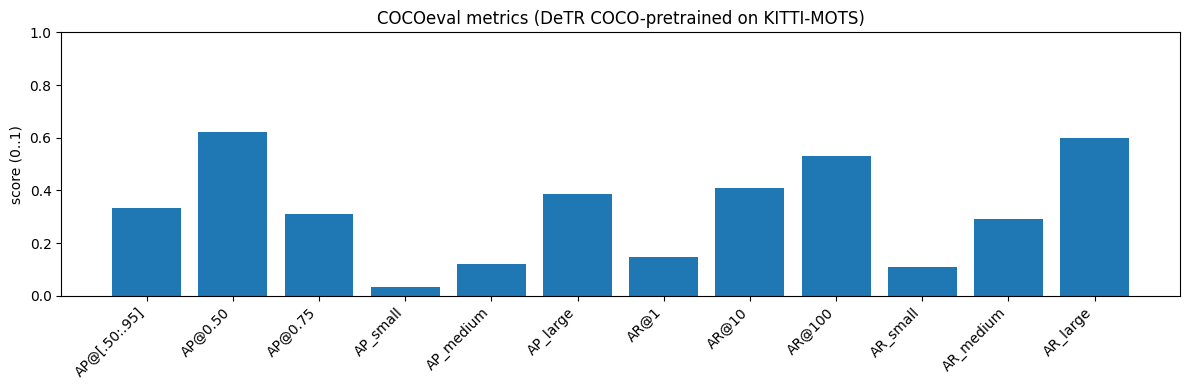

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Recuperar stats
# Si en la celda anterior guardaste: detr_stats = coco_eval_bbox(...)
# entonces usa detr_stats. Si no, intenta usar "_" (que tú asignaste).
# if "detr_ft_stats" in globals() and detr_ft_stats is not None:
#     stats = np.array(detr_ft_stats, dtype=float)
# elif "_" in globals() and _ is not None:
#     stats = np.array(_, dtype=float)
# else:
#     raise ValueError("No encuentro las métricas. Guarda el retorno: detr_stats = coco_eval_bbox(...) y vuelve a ejecutar.")

labels = [
    "AP@[.50:.95]", "AP@0.50", "AP@0.75", "AP_small", "AP_medium", "AP_large",
    "AR@1", "AR@10", "AR@100", "AR_small", "AR_medium", "AR_large"
]

# 2) Print tipo tabla
print("COCOeval stats (0..1):")
for name, val in zip(labels, stats):
    print(f"{name:>12}: {val:.3f}")

# 3) Plot (1 figura)
x = np.arange(len(labels))

plt.figure(figsize=(12, 4))
plt.bar(x, stats)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.title("COCOeval metrics (DeTR COCO-pretrained on KITTI-MOTS)")
plt.ylabel("score (0..1)")
plt.tight_layout()
plt.show()